## Introduction
Student dropout is a major challenge in higher education institutions, leading to wasted resources and reduced academic success rates. Early identification of students at risk of dropping out can help institutions take timely interventions such as academic support, financial aid, and counseling.

This project aims to develop a machine learning model that predicts whether a student is likely to drop out or graduate based on admission-level data.


The dataset used in our problem was got from Kaggle particularly UCI learning repository as the original source of the dataset.

Link: (https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)

It contains student information including demographic, academic, and socio-economic features.


In [ ]:
# --Importing libraries--
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# --Visualization Settings--
sns.set_style("whitegrid")


In [ ]:
# --Loading the dataset--
df = pd.read_csv('/content/sample_data/data.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 1. Data Understanding

In [ ]:
# --Checking the dataset structure--
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [ ]:
# --Checking the shape(number of records and variables/columns)
print(df.shape)

(4424, 37)


In [ ]:
# --Checking the columns in the dataset--
print(df.columns)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [ ]:
# --Summary statistics--
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
# --Checking for missing values--
print(df.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [ ]:
# --Checking distribution of target variables--
df["Target"].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794



The dataset contains three categories: Graduate, Dropout, and Enrolled.

# 2. Data Cleaning

In [ ]:
# Removing 'Enrolled' since outcome is unknown
df = df[df["Target"] != "Enrolled"]

# Converting Target to binary (Dropout = 1, Graduate = 0)
df["Target"] = df["Target"].map({
    "Dropout" : 1,
    "Graduate" : 0
})


The 'Enrolled' category was removed because it does not represent a final outcome.

# Target Distribution

In [ ]:
# Variable distribution after removing target enrolled

df["Target"].value_counts()

,count
Target,
0,2209
1,1421


# 3. Feature Selection

In [ ]:
# --Selecting relevant admission-time features--
X = df[[
    "Marital status",
    "Nacionality",
    "Educational special needs",
    "Age at enrollment",
    "Previous qualification",
    "Previous qualification (grade)"
    ]]

y = df["Target"]

# Variable Description for the selected features

The following features were selected for early dropout prediction as they are available at the admission stage.

## 1. Marital Status
Represents the student's marital condition.

| Code | Description |
|------|------------|
| 1 | Single |
| 2 | Married |
| 3 | Widower |
| 4 | Divorced |
| 5 | Facto union |
| 6 | Legally separated |

## 2. Previous Qualification
Represents the highest level of education attained before admission.

| Code | Description |
|------|------------|
| 1 | Secondary education |
| 2 | Higher education - bachelor's degree |
| 3 | Higher education - degree |
| 4 | Higher education - master's |
| 5 | Higher education - doctorate |
| 6 | Frequency of higher education |
| 9 | 12th year of schooling - not completed |
| 10 | 11th year of schooling - not completed |
| 12 | Other - 11th year of schooling |
| 14 | 10th year of schooling |
| 15 | 10th year of schooling - not completed |
| 19 | Basic education (3rd cycle) |
| 38 | Basic education (2nd cycle) |
| 39 | Technological specialization course |
| 40 | Higher education - degree (1st cycle) |
| 42 | Professional higher technical course |
| 43 | Higher education - master (2nd cycle) |

## 3. Previous Qualification (Grade)
Represents the grade obtained in the previous qualification.

- Range: **0 – 200**

## 4. Nationality
Represents the student's country of origin.

Examples:

| Code | Country |
|------|--------|
| 1 | Portuguese |
| 2 | German |
| 6 | Spanish |
| 11 | Italian |
| 13 | Dutch |
| 14 | English |
| 17 | Lithuanian |
| 21 | Angolan |
| 22 | Cape Verdean |
| 24 | Guinean |
| 25 | Mozambican |
| 26 | Santomean |
| 32 | Turkish |
| 41 | Brazilian |
| 62 | Romanian |
| 100 | Moldova (Republic of) |
| 101 | Mexican |
| 103 | Ukrainian |
| 105 | Russian |
| 108 | Cuban |
| 109 | Colombian |

## 5. Educational Special Needs
Indicates whether the student has special educational needs.

| Code | Description |
|------|------------|
| 0 | No |
| 1 | Yes |

## 6. Age at Enrollment
Represents the age of the student at the time of admission.



Selected Features
--
These features are available at admission and are relevant for early dropout prediction.

In [ ]:
# Initializing SelectKBest with Chi-square test
# k='all' means we evaluate all features instead of selecting a subset
selector = SelectKBest(score_func=chi2, k='all')

# Fitting the selector to the feature matrix (X) and target variable (y)
# This computes the relationship between each feature and the target
selector.fit(X, y)

# Creating a DataFrame to display feature names and their corresponding scores
scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

# Sorting features by importance (highest score = strongest relationship with dropout)
scores = scores.sort_values(by="Score", ascending=False)

# Displaying the feature importance scores
print(scores)

                          Feature       Score
3               Age at enrollment  676.872627
4          Previous qualification  312.510006
5  Previous qualification (grade)   57.332877
1                     Nacionality   21.247358
0                  Marital status   11.625477
2       Educational special needs    0.188890


## Feature Selection using Chi-Square Test

The Chi-square test was used to evaluate the relationship between each feature and the target variable (Dropout).

- Each feature is assigned a score based on how strongly it is associated with the target.
- Higher scores indicate more important features for predicting dropout.
- All features were evaluated (k = 'all') to allow comparison of their importance.

This helps in identifying which features contribute most to early dropout prediction.

## Interpretation of Results

- Features with higher scores have a stronger relationship with student dropout.
- These features are considered more important for prediction.
- Features with very low scores may have little influence and can be removed.

This step helps refine the model by focusing only on the most relevant variables.

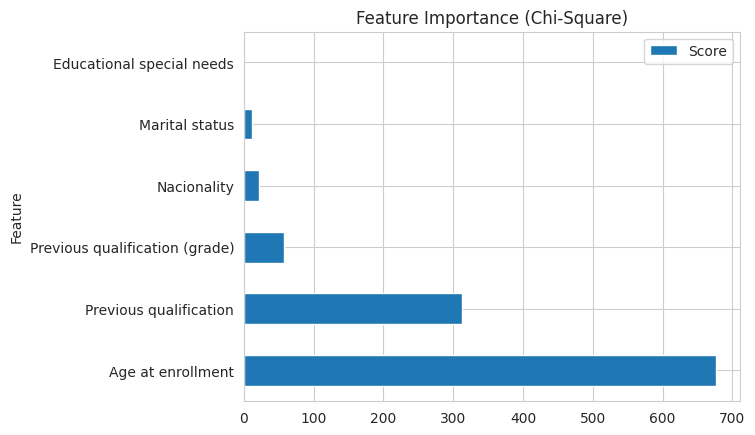

In [ ]:
# Visualizing results
scores.plot(x="Feature", y="Score", kind="barh")
plt.title("Feature Importance (Chi-Square)")
plt.show()

# 4. Exploratory Data Analysis (EDA)
In this section, we explore patterns in the data before model training.

## EDA Objectives
- Understand the distribution of the target class (Dropout vs Graduate).
- Explore how demographic and academic features vary across target groups.
- Identify potential outliers, skewness, and feature relationships.
- Build intuition about which variables may be strong dropout indicators.

## What to Look For in the Plots
- Class imbalance in the target distribution.
- Clear separation between dropout and graduate groups.
- Categories with consistently higher dropout rates.
- Correlated features that may affect model behavior.

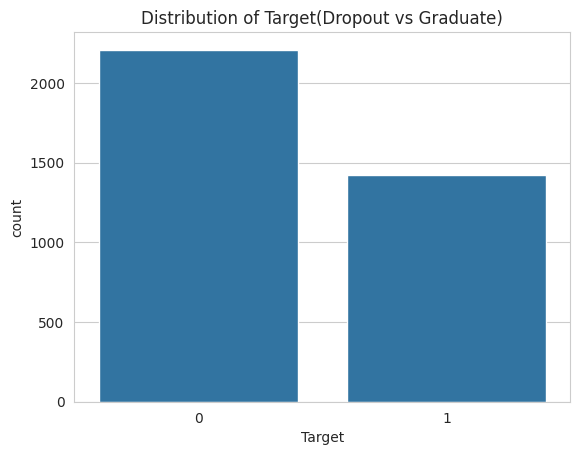

In [ ]:
# Checking class balance for the prediction target.
sns.countplot(x="Target", data=df)
plt.title("Distribution of Target(Dropout vs Graduate)")
plt.show()

Text(0.5, 1.0, 'Age at Enrollment vs Dropout')

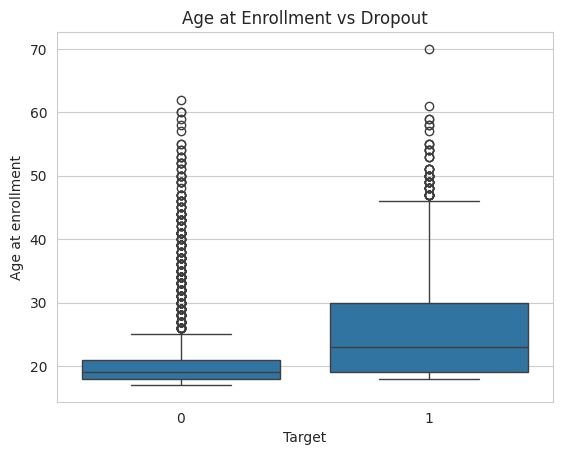

In [ ]:
# Comparing age distribution across target classes using quartiles and outliers.
sns.boxplot(x="Target", y="Age at enrollment", data=df)
plt.title("Age at Enrollment vs Dropout")

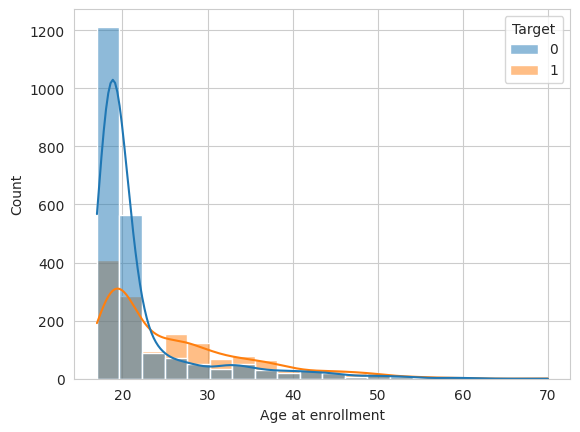

In [ ]:
# Inspecting age distribution shape by class (histogram + KDE).
sns.histplot(data=df, x="Age at enrollment", hue="Target", bins=20, kde=True)
plt.show()

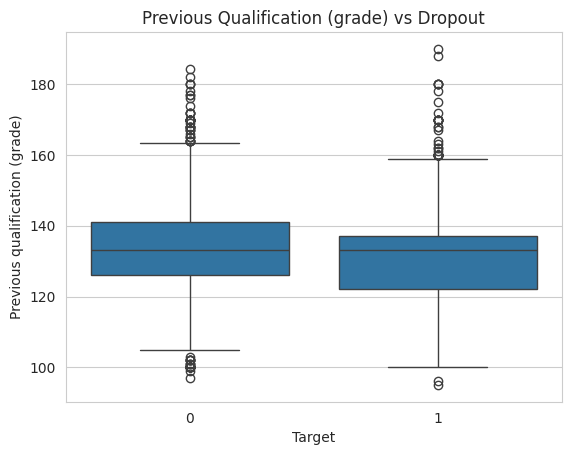

In [ ]:
# Comparing prior academic grade distributions between target classes.
sns.boxplot(x="Target", y="Previous qualification (grade)", data=df)
plt.title("Previous Qualification (grade) vs Dropout")
plt.show()

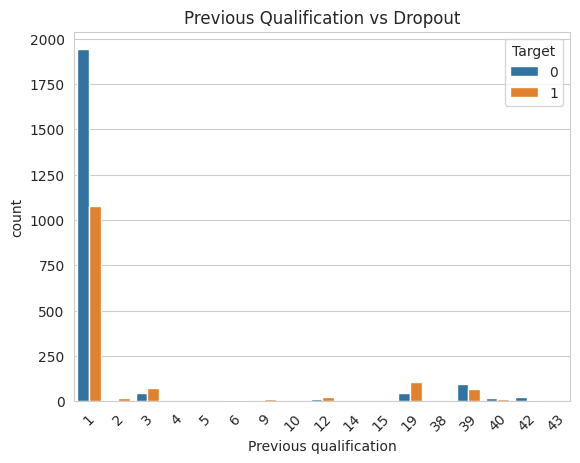

In [ ]:
# Visualizing how previous qualification categories relate to dropout outcomes.
sns.countplot(x="Previous qualification", hue="Target", data=df)
plt.title("Previous Qualification vs Dropout")
plt.xticks(rotation=45)
plt.show()

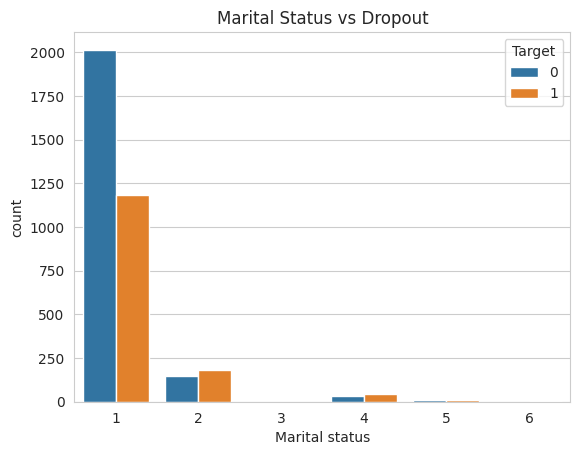

In [ ]:
# Comparing marital status categories across target classes.
sns.countplot(x="Marital status", hue="Target", data=df)
plt.title("Marital Status vs Dropout")
plt.show()

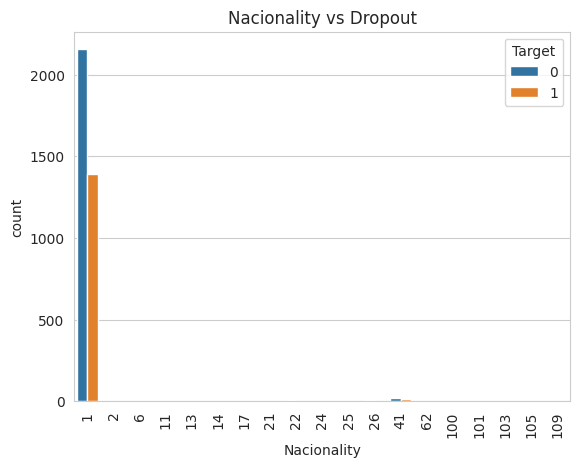

In [ ]:
# Exploring nationality distribution by target class.
sns.countplot(x="Nacionality", hue="Target", data=df)
plt.title("Nacionality vs Dropout")
plt.xticks(rotation=90)
plt.show()

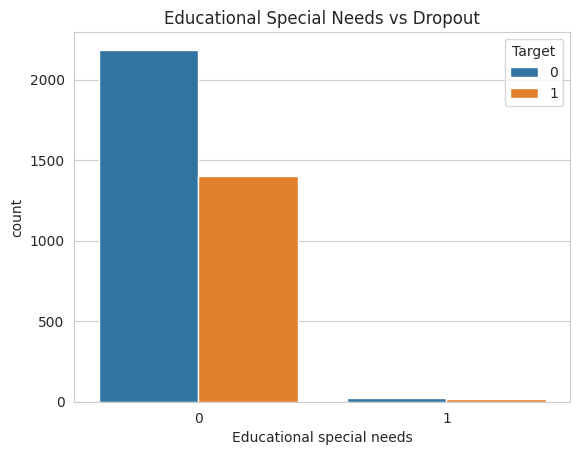

In [ ]:
# Checking if students with special needs show different dropout patterns.
sns.countplot(x="Educational special needs", hue="Target", data=df)
plt.title("Educational Special Needs vs Dropout")
plt.show()

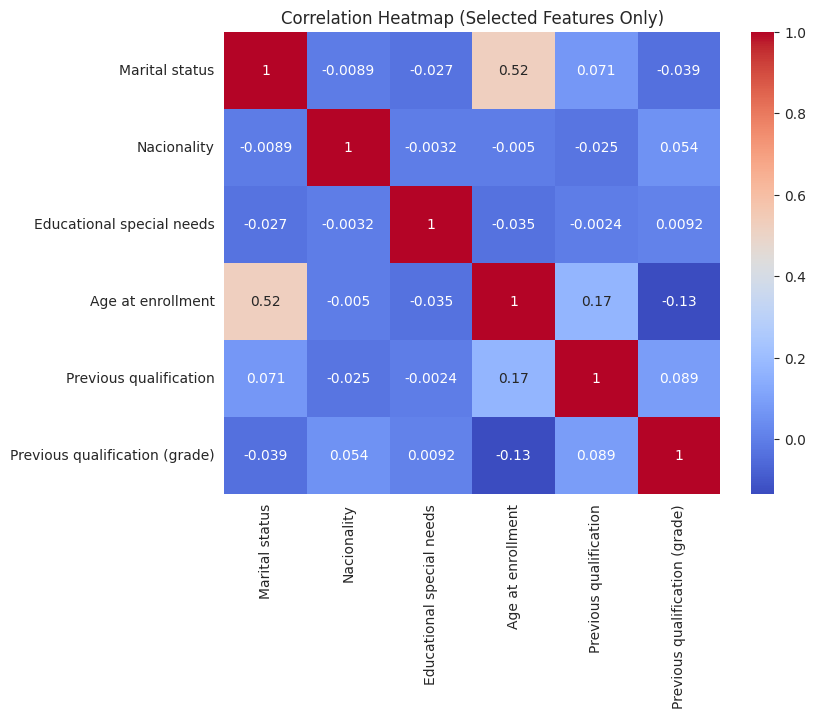

In [ ]:
# Correlation heatmap for selected numeric features.
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Selected Features Only)")
plt.show()

In [ ]:
#computing and plotting dropout rate (mean target) for each category/value of a feature.
def plot_dropout_rate(feature):
    dropout_rate = df.groupby(feature)["Target"].mean().sort_values()

    dropout_rate.plot(kind='bar')
    plt.title(f"Dropout Rate by {feature}")
    plt.ylabel("Dropout Rate (0 to 1)")
    plt.xlabel(feature)
    plt.show()

### Dropout Rate Analysis

The next plots summarize dropout risk by feature value.

- Since Target is encoded as 0/1, the group-wise mean of Target equals the dropout rate.
- Values closer to 1 indicate higher dropout likelihood.
- This view complements count plots by normalizing for group size.

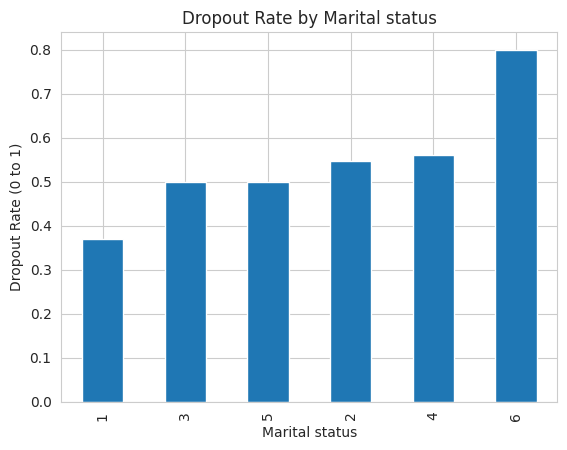

In [ ]:
# Dropout rate across marital status categories.
plot_dropout_rate("Marital status")

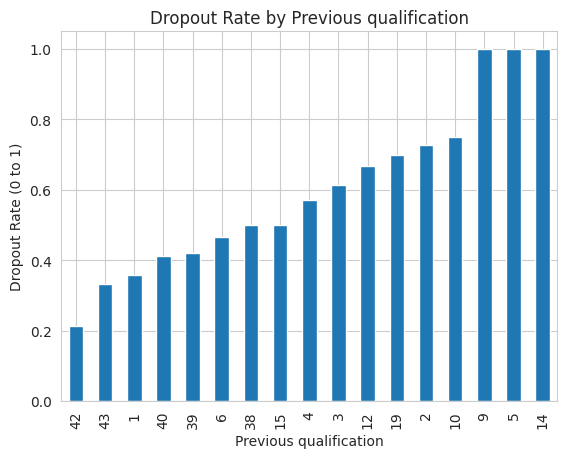

In [ ]:
# Dropout rate across previous qualification categories.
plot_dropout_rate("Previous qualification")

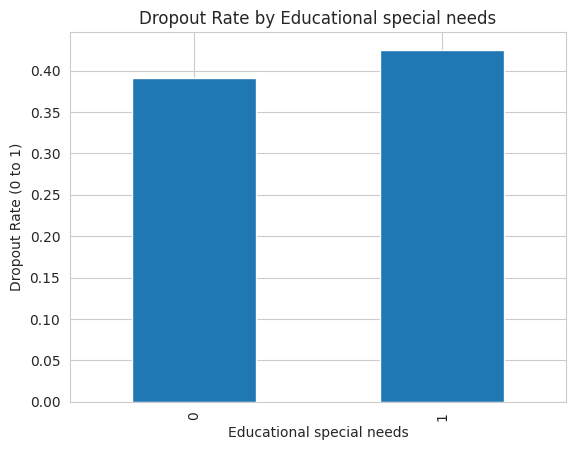

In [ ]:
# Dropout rate comparison for educational special needs status.
plot_dropout_rate("Educational special needs")

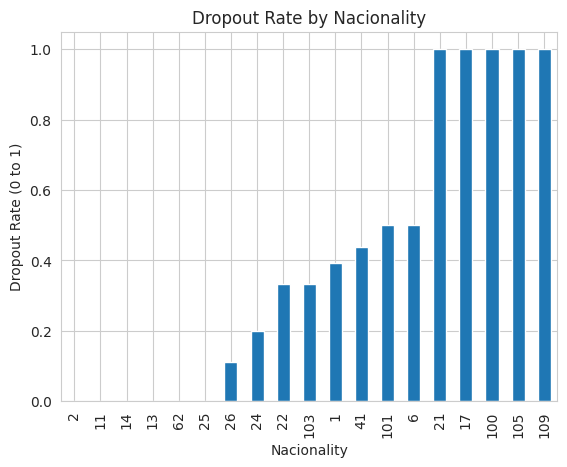

In [ ]:
# Dropout rate by nationality.
plot_dropout_rate("Nacionality")

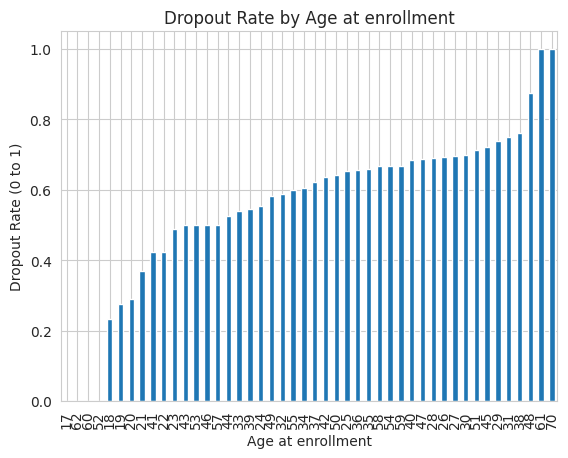

In [ ]:
# Dropout rate by age at enrollment (treated as grouped values in the dataset).
plot_dropout_rate("Age at enrollment")

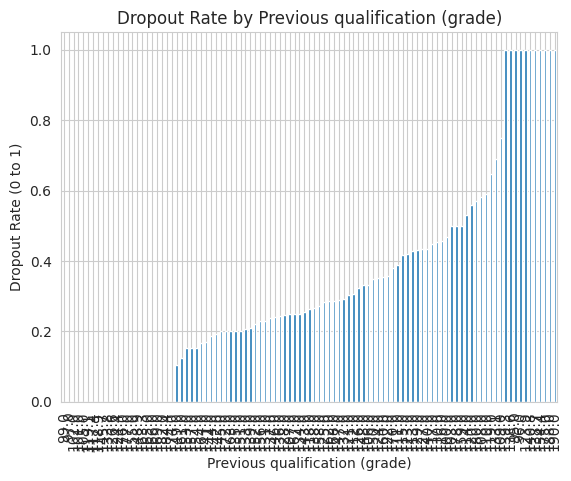

In [ ]:
# Dropout rate by previous qualification grade.
plot_dropout_rate("Previous qualification (grade)")

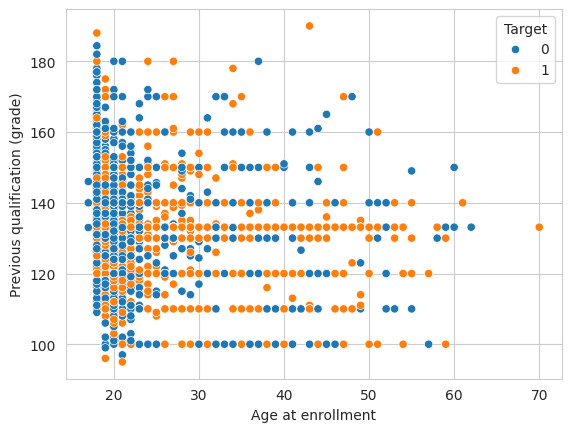

In [ ]:
# Bivariate view: relationship between age and prior grade, colored by target class.
sns.scatterplot(x="Age at enrollment", y="Previous qualification (grade)", hue="Target", data=df)
plt.show()

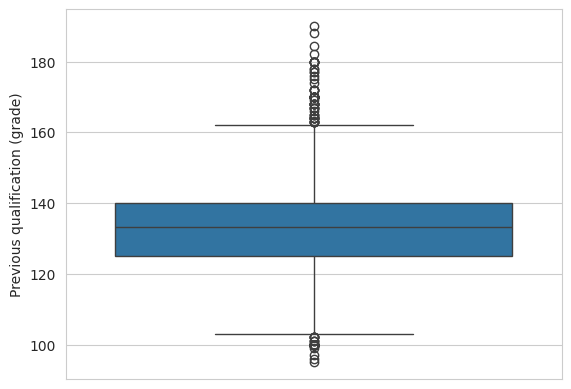

In [ ]:
# Univariate outlier check for previous qualification grade.
sns.boxplot(df["Previous qualification (grade)"])
plt.show()

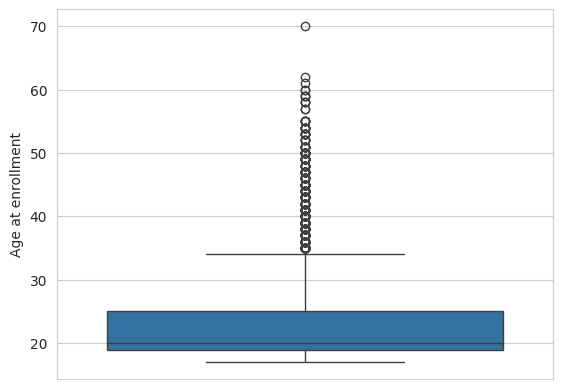

In [ ]:
# Univariate outlier check for age at enrollment.
sns.boxplot(df["Age at enrollment"])
plt.show()

### EDA Summary

Key observations:
- The target distribution indicates whether class imbalance handling is needed.
- Age and previous qualification grade show distribution differences across classes.
- Some categorical groups display higher dropout rates than others.
- Correlation and outlier checks guide feature treatment before modeling.

These insights support feature engineering and model selection in the next stage.

#Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Training the Logistic Regression Model

In [ ]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6887052341597796
              precision    recall  f1-score   support

           0       0.69      0.90      0.78       449
           1       0.68      0.35      0.46       277

    accuracy                           0.69       726
   macro avg       0.68      0.62      0.62       726
weighted avg       0.69      0.69      0.66       726



#Training the Decision Tree Model

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6542699724517906
              precision    recall  f1-score   support

           0       0.68      0.83      0.75       449
           1       0.57      0.38      0.45       277

    accuracy                           0.65       726
   macro avg       0.63      0.60      0.60       726
weighted avg       0.64      0.65      0.64       726



#Training the Random Forest Model

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6652892561983471
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       449
           1       0.58      0.44      0.50       277

    accuracy                           0.67       726
   macro avg       0.64      0.62      0.62       726
weighted avg       0.65      0.67      0.65       726



#Comparing the accuracy of the three baseline models

In [ ]:
print("Logistic Regression (Baseline):")
print(classification_report(y_test, y_pred_lr))

print("Decision Tree (Baseline):")
print(classification_report(y_test, y_pred_dt))

print("Random Forest (Baseline):")
print(classification_report(y_test, y_pred_rf))

Logistic Regression (Baseline):
              precision    recall  f1-score   support

           0       0.69      0.90      0.78       449
           1       0.68      0.35      0.46       277

    accuracy                           0.69       726
   macro avg       0.68      0.62      0.62       726
weighted avg       0.69      0.69      0.66       726

Decision Tree (Baseline):
              precision    recall  f1-score   support

           0       0.68      0.83      0.75       449
           1       0.57      0.38      0.45       277

    accuracy                           0.65       726
   macro avg       0.63      0.60      0.60       726
weighted avg       0.64      0.65      0.64       726

Random Forest (Baseline):
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       449
           1       0.58      0.44      0.50       277

    accuracy                           0.67       726
   macro avg       0.64      0.62      0.62 

#Comparing the three baseline models using their confusion matrices

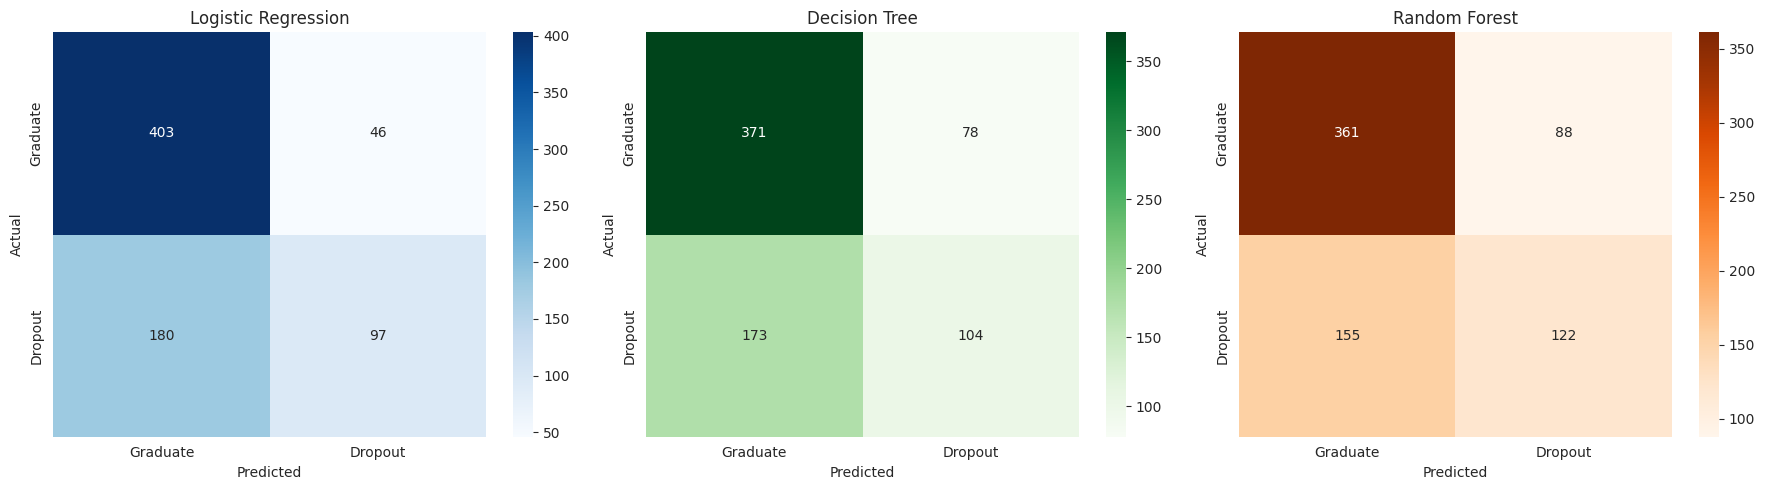

In [ ]:
# Create confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Baseline Model Evaluation

From the evaluation metrics and confusion matrices, it is observed that the three baseline models : Logistic Regression, Decision Tree, and Random Forest, achieve moderate overall accuracy. However, a deeper analysis reveals that this performance is misleading.

All three models perform well in predicting the majority class (Graduate), but poorly in identifying the minority class (Dropout), as indicated by the low recall for dropout cases. Since the primary objective of this study is to accurately identify students at risk of dropping out, this limitation is critical.

To address this issue, class imbalance handling techniques are introduced. By applying class weighting, the models are encouraged to give more importance to dropout cases. Improved models are then trained with the aim of increasing recall for the dropout class while maintaining reasonable overall performance.

## Model Improvement: Handling Class Imbalance
To improve dropout detection, class weights were introduced to give more importance to the minority class (Dropout).

In [ ]:
## Training the models with class balancing
# Logistic Regression
model_lr_bal = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_lr_bal.fit(X_train, y_train)
y_pred_lr_bal = model_lr_bal.predict(X_test)

# Decision Tree
model_dt_bal = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model_dt_bal.fit(X_train, y_train)
y_pred_dt_bal = model_dt_bal.predict(X_test)

# Random Forest
model_rf_bal = RandomForestClassifier(class_weight='balanced', random_state=42)
model_rf_bal.fit(X_train, y_train)
y_pred_rf_bal = model_rf_bal.predict(X_test)

#Evaluation metrics for the improved models

In [ ]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr_bal))

print("Decision Tree")
print(classification_report(y_test, y_pred_dt_bal))

print("Random Forest")
print(classification_report(y_test, y_pred_rf_bal))

Logistic Regression
              precision    recall  f1-score   support

           0       0.74      0.75      0.75       449
           1       0.59      0.57      0.58       277

    accuracy                           0.68       726
   macro avg       0.66      0.66      0.66       726
weighted avg       0.68      0.68      0.68       726

Decision Tree
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       449
           1       0.57      0.55      0.56       277

    accuracy                           0.67       726
   macro avg       0.65      0.65      0.65       726
weighted avg       0.67      0.67      0.67       726

Random Forest
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       449
           1       0.56      0.52      0.54       277

    accuracy                           0.66       726
   macro avg       0.64      0.64      0.64       726
weighted avg       0.66   

### Improved Model Evaluation (After Handling Class Imbalance)

After applying class balancing, the performance of all three models improved, particularly in detecting dropout cases.

Logistic Regression achieved the best overall performance, with a dropout recall of 0.57 and the highest F1-score (0.58) for the dropout class. This indicates a better balance between correctly identifying dropout students and minimizing errors.

The Decision Tree model showed slightly lower performance, with a dropout recall of 0.55 and F1-score of 0.56, while Random Forest performed the weakest among the three in detecting dropouts, with a recall of 0.52.

Although all models maintain similar overall accuracy (approximately 66–68%), accuracy alone is not sufficient for this problem. The key objective is to correctly identify students at risk of dropping out, making recall for the dropout class the most important metric.

Based on this, Logistic Regression is selected as the best model, as it achieves the highest recall and F1-score for dropout prediction while maintaining stable overall performance.

#Comparing the improved models using their confusion matrices

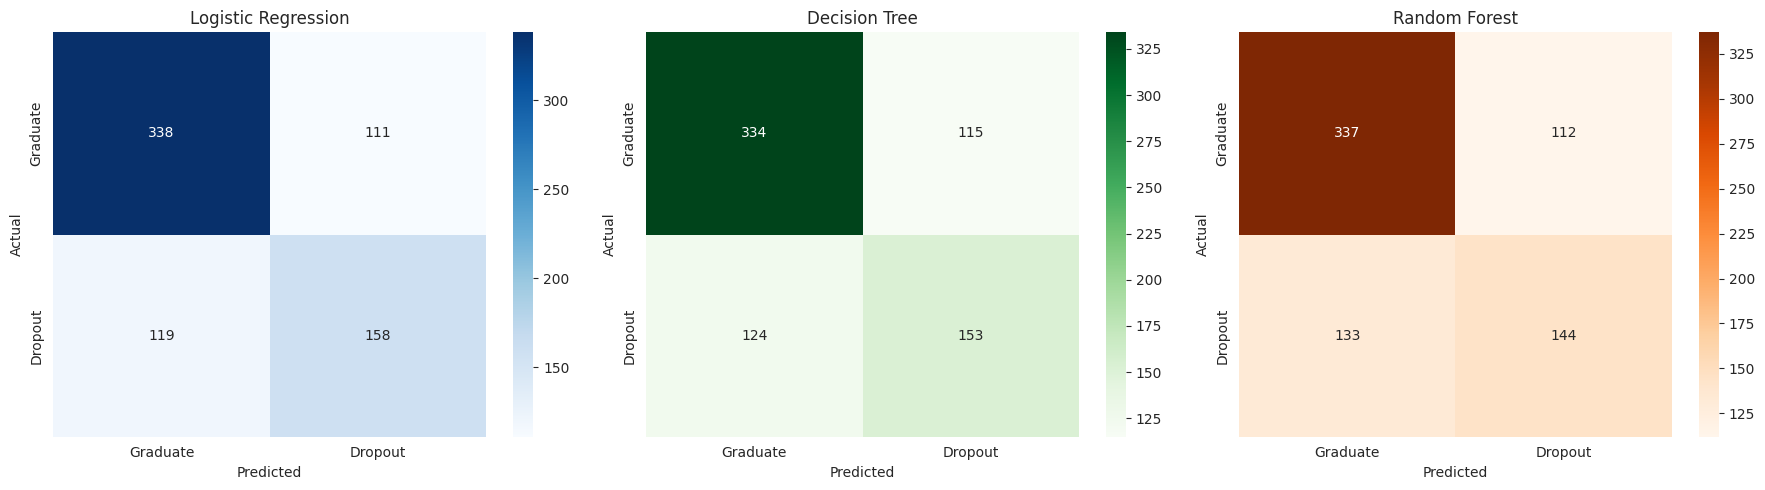

In [ ]:
# Create confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr_bal)
cm_dt = confusion_matrix(y_test, y_pred_dt_bal)
cm_rf = confusion_matrix(y_test, y_pred_rf_bal)

# Create subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

The confusion matrices provide deeper insight into how well each model identifies dropout cases.

Logistic Regression:
- True Positives (Dropouts correctly identified): 158  
- False Negatives (Missed dropouts): 119  

Decision Tree:
- True Positives: 153  
- False Negatives: 124  

Random Forest:
- True Positives: 144  
- False Negatives: 133  

From this analysis, Logistic Regression performs best in detecting dropout cases, as it correctly identifies the highest number of dropouts (158) and has the lowest number of missed dropout cases (119).

Since false negatives represent students who are at risk but are not identified by the model, minimizing them is critical. Therefore, Logistic Regression is preferred as it provides better coverage of at-risk students compared to the other models.

# Training Advanced models using Hyperparameter Tuning

### Random Forest

The Random Forest model is tuned to optimize its ensemble learning performance.

Parameters such as number of trees and tree depth are adjusted to improve recall.

In [ ]:
# Define model
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
}

# Grid Search
grid = GridSearchCV(rf, param_grid, cv=5, scoring='recall', n_jobs=-1)

# Train
grid.fit(X_train, y_train)

# Best model
best_rf = grid.best_estimator_

# Predictions
y_pred_rf_adv = best_rf.predict(X_test)

In [ ]:
print("Advanced Random Forest:")
print(classification_report(y_test, y_pred_rf_adv))

Advanced Random Forest:
              precision    recall  f1-score   support

           0       0.74      0.75      0.74       449
           1       0.58      0.58      0.58       277

    accuracy                           0.68       726
   macro avg       0.66      0.66      0.66       726
weighted avg       0.68      0.68      0.68       726



### Logistic Regression

Logistic Regression is further improved using hyperparameter tuning to optimize its performance.

The tuning focuses on adjusting the regularization strength and solver to improve recall for the dropout class.

In [ ]:
# Define Base model
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Define Parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

# Grid search for tuning
grid_lr = GridSearchCV(lr, param_grid, cv=5, scoring='recall', n_jobs=-1)

# Train
grid_lr.fit(X_train, y_train)

# Best model
best_lr = grid_lr.best_estimator_

# Predict
y_pred_lr_adv = best_lr.predict(X_test)

In [ ]:
print("Advanced Logistic Regression:")
print(classification_report(y_test, y_pred_lr_adv))

Advanced Logistic Regression:
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       449
           1       0.59      0.56      0.57       277

    accuracy                           0.68       726
   macro avg       0.66      0.66      0.66       726
weighted avg       0.68      0.68      0.68       726



The tuned Logistic Regression model performs slightly poorer than the improved model.

### Decision Tree

The Decision Tree model is tuned to control its complexity and improve generalization.

Parameters such as tree depth and minimum samples per split are optimized.

In [ ]:
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring='recall',
    cv=5
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt_adv = best_dt.predict(X_test)

In [ ]:
print("Advanced Decision Tree (Tuned):")
print("Best Parameters:", grid_dt.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_dt_adv))
print(classification_report(y_test, y_pred_dt_adv))

Advanced Decision Tree (Tuned):
Best Parameters: {'max_depth': 5, 'min_samples_split': 10}
Accuracy: 0.6873278236914601
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       449
           1       0.59      0.57      0.58       277

    accuracy                           0.69       726
   macro avg       0.67      0.67      0.67       726
weighted avg       0.69      0.69      0.69       726



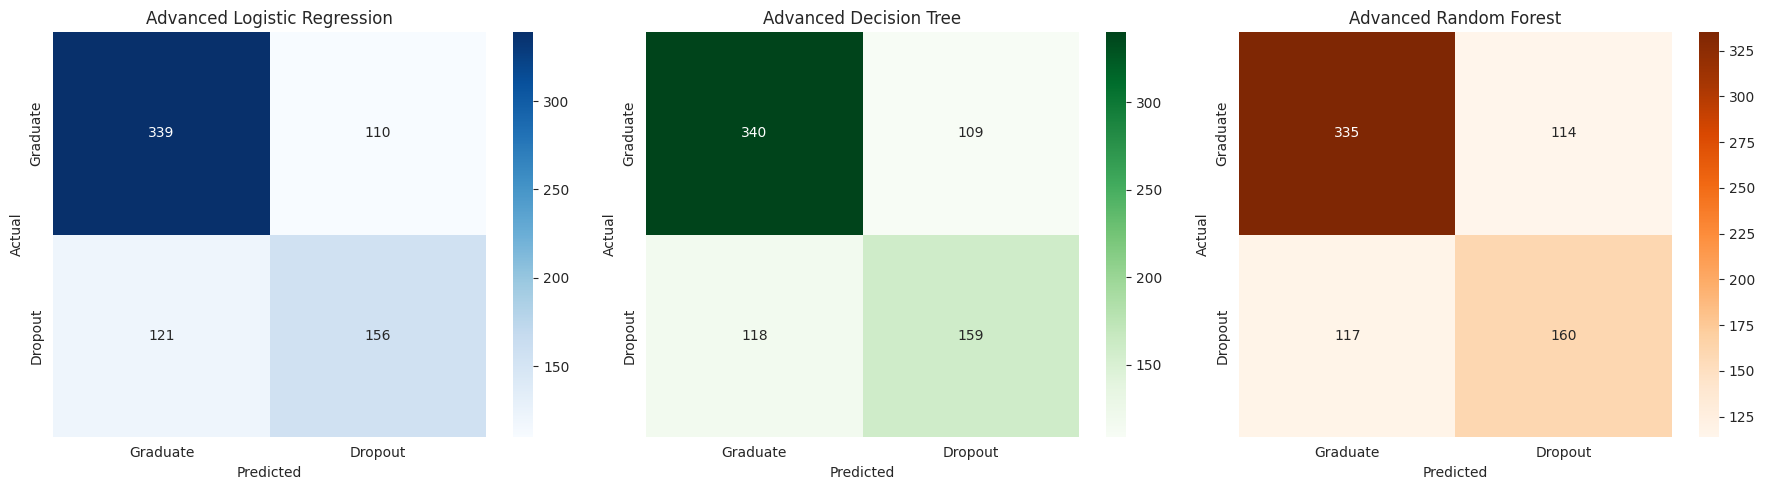

In [ ]:
# Compute confusion matrices
cm_lr_adv = confusion_matrix(y_test, y_pred_lr_adv)
cm_dt_adv = confusion_matrix(y_test, y_pred_dt_adv)
cm_rf_adv = confusion_matrix(y_test, y_pred_rf_adv)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(cm_lr_adv, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[0])
axes[0].set_title("Advanced Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Decision Tree
sns.heatmap(cm_dt_adv, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[1])
axes[1].set_title("Advanced Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Random Forest
sns.heatmap(cm_rf_adv, annot=True, fmt='d', cmap='Oranges',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[2])
axes[2].set_title("Advanced Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Comparison of Advanced Models

The advanced models were evaluated and compared using classification metrics and confusion matrices.

After tuning, the Decision tree and Random Forest advanced models showed significant improvement over Logistic Regression.


# Training one more model(Gradient Boosting Model)

In [ ]:
# Train model
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train, y_train)

# Predict
y_pred_gb = model_gb.predict(X_test)

In [ ]:
# Train model
model_gb_base = GradientBoostingClassifier(random_state=42)
model_gb_base.fit(X_train, y_train)

# Predict
y_pred_gb_base = model_gb_base.predict(X_test)

print("Gradient Boosting (Baseline):")
print("Accuracy:", accuracy_score(y_test, y_pred_gb_base))
print(classification_report(y_test, y_pred_gb_base))

Gradient Boosting (Baseline):
Accuracy: 0.6928374655647382
              precision    recall  f1-score   support

           0       0.72      0.81      0.77       449
           1       0.62      0.50      0.55       277

    accuracy                           0.69       726
   macro avg       0.67      0.66      0.66       726
weighted avg       0.69      0.69      0.68       726



In [ ]:
# Compute weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Train with weights
model_gb_bal = GradientBoostingClassifier(random_state=42)
model_gb_bal.fit(X_train, y_train, sample_weight=sample_weights)

# Predict
y_pred_gb_bal = model_gb_bal.predict(X_test)

print("Gradient Boosting (Balanced):")
print("Accuracy:", accuracy_score(y_test, y_pred_gb_bal))
print(classification_report(y_test, y_pred_gb_bal))


Gradient Boosting (Balanced):
Accuracy: 0.6721763085399449
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       449
           1       0.57      0.60      0.58       277

    accuracy                           0.67       726
   macro avg       0.65      0.66      0.66       726
weighted avg       0.68      0.67      0.67       726



In [ ]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

# Initialize GridSearchCV
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# Train model
grid_gb.fit(X_train, y_train)

# Get best model
best_gb = grid_gb.best_estimator_

# Make predictions
y_pred_gb_adv = best_gb.predict(X_test)

# Evaluate model
print("Advanced Gradient Boosting (Tuned):")
print("Best Parameters:", grid_gb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_gb_adv))
print(classification_report(y_test, y_pred_gb_adv))


Advanced Gradient Boosting (Tuned):
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Accuracy: 0.699724517906336
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       449
           1       0.63      0.52      0.57       277

    accuracy                           0.70       726
   macro avg       0.68      0.66      0.67       726
weighted avg       0.69      0.70      0.69       726



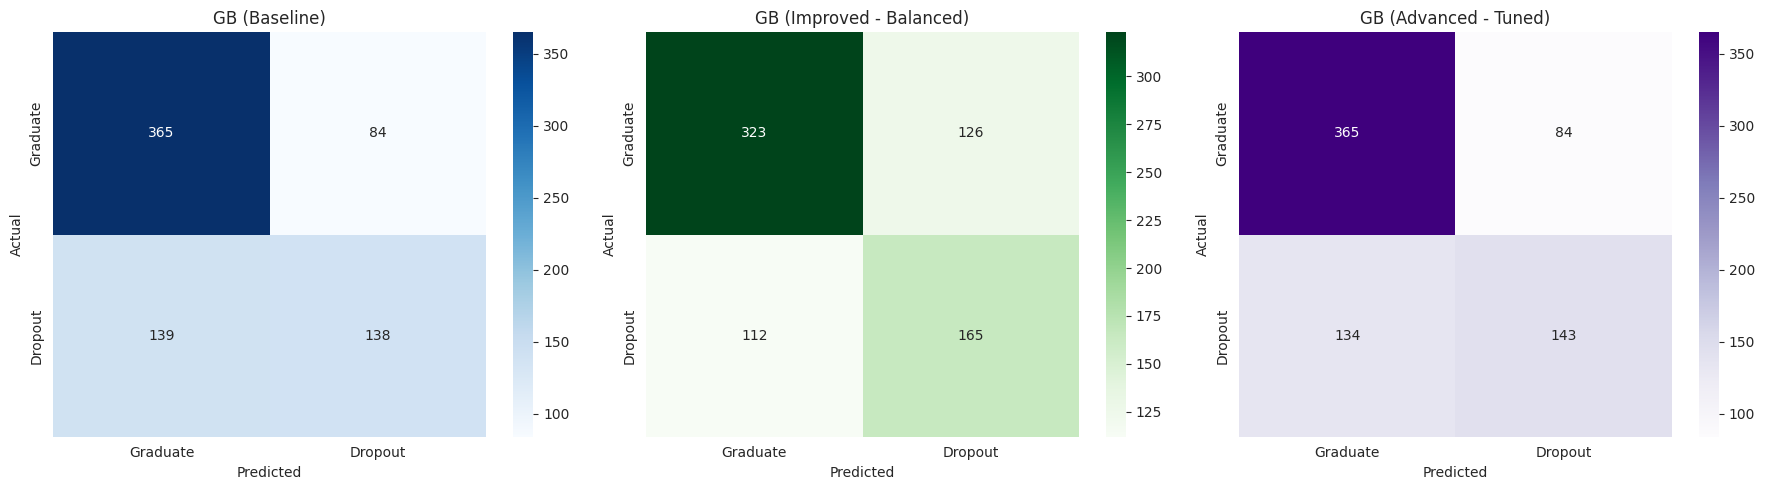

In [ ]:
# Compute confusion matrices
cm_gb_base = confusion_matrix(y_test, y_pred_gb_base)   # baseline
cm_gb_bal = confusion_matrix(y_test, y_pred_gb_bal)         # improved (balanced)
cm_gb_adv = confusion_matrix(y_test, y_pred_gb_adv)     # advanced (tuned)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Baseline GB
sns.heatmap(cm_gb_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[0])
axes[0].set_title("GB (Baseline)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Improved GB
sns.heatmap(cm_gb_bal, annot=True, fmt='d', cmap='Greens',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[1])
axes[1].set_title("GB (Improved - Balanced)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Advanced GB
sns.heatmap(cm_gb_adv, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Graduate", "Dropout"],
            yticklabels=["Graduate", "Dropout"],
            ax=axes[2])
axes[2].set_title("GB (Advanced - Tuned)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### Final Model Comparison and Insights

The performance of baseline, improved, and advanced models reveals several important patterns:

- The advanced Logistic Regression model performed slightly worse than its improved (balanced) version, indicating that hyperparameter tuning did not enhance its ability to detect dropout cases.

- The advanced Decision Tree model showed improvement over its improved version, suggesting that tuning helped control model complexity and improve generalization.

- The advanced Random Forest model also performed better than its improved version and emerged as the best among the three traditional models (Logistic Regression, Decision Tree, and Random Forest).

- However, the improved Gradient Boosting model outperformed all three models, achieving the best performance in detecting dropout cases.

- Interestingly, the advanced (tuned) Gradient Boosting model performed worse than its improved version, indicating that hyperparameter tuning did not improve performance and may have reduced its effectiveness.

### Key Insight

These results highlight that model performance is not solely dependent on increasing complexity. In this case, handling class imbalance had a greater impact than hyperparameter tuning.

This reinforces the importance of aligning modeling techniques with the problem objective — accurately identifying students at risk of dropping out.

In [ ]:
import joblib

joblib.dump(model_gb_bal, "dropout_model.pkl")

['dropout_model.pkl']

In [ ]:
print(X.columns)

Index(['Marital status', 'Nacionality', 'Educational special needs',
       'Age at enrollment', 'Previous qualification',
       'Previous qualification (grade)'],
      dtype='object')
